# 01 — Analyse exploratoire des données (EDA)

**But :** comprendre les données avant de construire les modèles. On répond à ces questions :

1. Combien de décisions, sur quelles années, dans quelles chambres ?
2. Quelles sont les issues (rejet, cassation…) et sont-elles équilibrées ?
3. Quelle est la longueur des textes ? (important : CamemBERT ne lit que 512 tokens)
4. Les champs utiles (zones, visa…) sont-ils remplis ?
5. Quels mots distinguent les issues ?

**Données :** les **553 075** arrêts de la Cour de cassation (Judilibre, via Hugging Face).
Le fichier brut (1 Go) a été résumé par `scripts/prepare_data.py` en une ligne de statistiques par décision (`stats_all.parquet`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
FIG = "../figures"
os.makedirs(FIG, exist_ok=True)

stats = pd.read_parquet("../data/processed/stats_all.parquet")
corpus = pd.read_parquet("../data/processed/corpus_model.parquet")
print(f"{len(stats):,} décisions | {stats.shape[1]} colonnes de statistiques")
stats.head()

553,075 décisions | 18 colonnes de statistiques


,id,date,year,chamber,solution,label,published,n_words,has_zones,zone_introduction,zone_expose,zone_moyens,zone_motivations,zone_dispositif,zone_annexes,n_visa,has_contested,has_summary
0,6079411b9ba5988459c4064e,1860-08-01,1860,Première chambre civile,Annulation,Autre,True,502,False,False,False,False,False,False,False,1,True,True
1,60794ccc9ba5988459c47129,1899-11-29,1899,Première chambre civile,Cassation,Cassation,True,491,False,False,False,False,False,False,False,1,True,False
2,61372090cd580146773ebaa6,1900-04-28,1900,Première chambre civile,Rejet,Rejet,False,208,False,False,False,False,False,False,False,0,True,False
3,61372095cd580146773ebf27,1912-07-30,1912,Première chambre civile,Rejet,Rejet,False,416,False,False,False,False,False,False,False,0,True,False
4,61372090cd580146773ebaa8,1915-08-03,1915,Première chambre civile,Rejet,Rejet,False,582,False,False,False,False,False,False,False,2,True,False


## 1. À quoi ressemble une décision ?

Un arrêt de la Cour de cassation est découpé en **zones** (repérées par Judilibre) :

| Zone | Rôle |
|---|---|
| Introduction | en-tête : cour, chambre, date, numéro de pourvoi, parties |
| Exposé | les faits et la procédure |
| Moyens | les arguments de la partie qui attaque la décision |
| Motivations | le raisonnement de la Cour |
| Dispositif | la décision finale (« PAR CES MOTIFS… ») |

Voici un exemple (début de chaque zone) :

In [2]:
ex = corpus[(corpus["label"] == "Cassation") & (corpus["date"] >= "2016")].iloc[0]
print("Date :", ex["date"], "| Chambre :", ex["chamber"], "| Issue :", ex["solution"])
for zone in ["introduction", "motivations", "dispositif"]:
    print(f"\n===== {zone.upper()} =====")
    print(ex[zone][:700].strip(), "…")

Date : 2016-01-19 | Chambre : Chambre commerciale financière et économique | Issue : Cassation

===== INTRODUCTION =====
COMM.
 
 MF 
 
 COUR DE CASSATION
 ______________________
 
 
 Audience publique du 19 janvier 2016 
 
 
 Cassation partielle
 
 
 Mme MOUILLARD, président 
 
 
 Arrêt n° 72 FS-P+B
 
 Pourvoi n° H 14-19.796
 
 
 
 
 
 R É P U B L I Q U E F R A N Ç A I S E 
 
 _________________________
 
 AU NOM DU PEUPLE FRANÇAIS
 _________________________
 
 
 LA COUR DE CASSATION, CHAMBRE COMMERCIALE, FINANCIÈRE ET ÉCONOMIQUE, a rendu l'arrêt suivant :
 
 Statuant sur le pourvoi formé par la société GIE C9, groupement d'intérêt économique, dont le siège est [Adresse 2],
 
 contre l'arrêt rendu le 9 avril 2014 par la cour d'appel de Riom (chambre commerciale), dans le litige l'opposant à M. [F] [P], domicil …

===== MOTIVATIONS =====
Vu l'article L. 251-1 du code de commerce ;
 
 Attendu qu'il résulte de ce texte que si le but du groupement d'intérêt économique n'est pas de réaliser

## 2. Répartition dans le temps

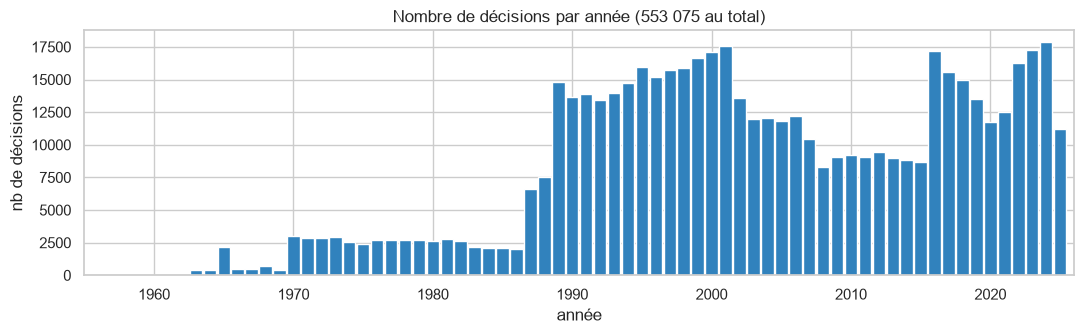

Période : 1860 → 2025
Part des décisions après 1970 : 99.1%


In [3]:
per_year = stats["year"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(per_year.index, per_year.values, color="#3182bd", width=0.9)
ax.set_xlim(1955, 2026); ax.set_xlabel("année"); ax.set_ylabel("nb de décisions")
ax.set_title("Nombre de décisions par année (553 075 au total)")
plt.tight_layout(); plt.savefig(f"{FIG}/eda_per_year.png", dpi=150); plt.show()

print(f"Période : {stats['year'].min()} → {stats['year'].max()}")
print(f"Part des décisions après 1970 : {(stats['year'] >= 1970).mean():.1%}")

**Observation :** presque toutes les décisions datent d'après 1970, avec un pic dans les années 1990-2000.
Les décisions très anciennes (XIXe siècle) sont anecdotiques.

## 3. Les issues (la variable à prédire)

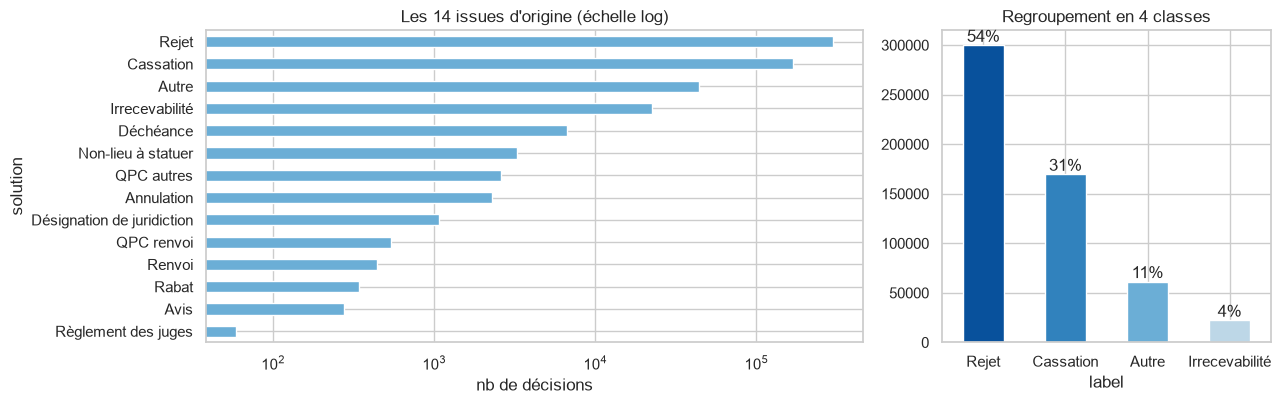

,nombre,part
solution,,
Rejet,299765,0.5420
Cassation,169592,0.3066
Autre,43833,0.0793
Irrecevabilité,22351,0.0404
Déchéance,6643,0.0120
Non-lieu à statuer,3284,0.0059
QPC autres,2612,0.0047
Annulation,2277,0.0041
Désignation de juridiction,1063,0.0019


In [4]:
sol = stats["solution"].value_counts()
lab = stats["label"].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [2, 1]})
sol.plot.barh(ax=ax[0], color="#6baed6"); ax[0].invert_yaxis(); ax[0].set_xscale("log")
ax[0].set_title("Les 14 issues d'origine (échelle log)"); ax[0].set_xlabel("nb de décisions")
lab.plot.bar(ax=ax[1], color=["#08519c", "#3182bd", "#6baed6", "#bdd7e7"]); ax[1].set_title("Regroupement en 4 classes")
ax[1].tick_params(axis="x", rotation=0)
for c in ax[1].containers: ax[1].bar_label(c, labels=[f"{v/len(stats):.0%}" for v in lab.values])
plt.tight_layout(); plt.savefig(f"{FIG}/eda_labels.png", dpi=150); plt.show()

pd.DataFrame({"nombre": sol, "part": (sol / len(stats)).round(4)})

**Observations :**
- Deux issues dominent : **Rejet (54 %)** et **Cassation (31 %)**.
- 12 issues rares se partagent le reste. On les regroupe : *Irrecevabilité* (4 %) est gardée à part car assez fréquente,
  les autres forment la classe *Autre*.
- Les classes sont **déséquilibrées** : il faudra une métrique qui ne favorise pas la classe majoritaire (**F1 macro**)
  et des poids de classe pendant l'entraînement.

## 4. Les chambres

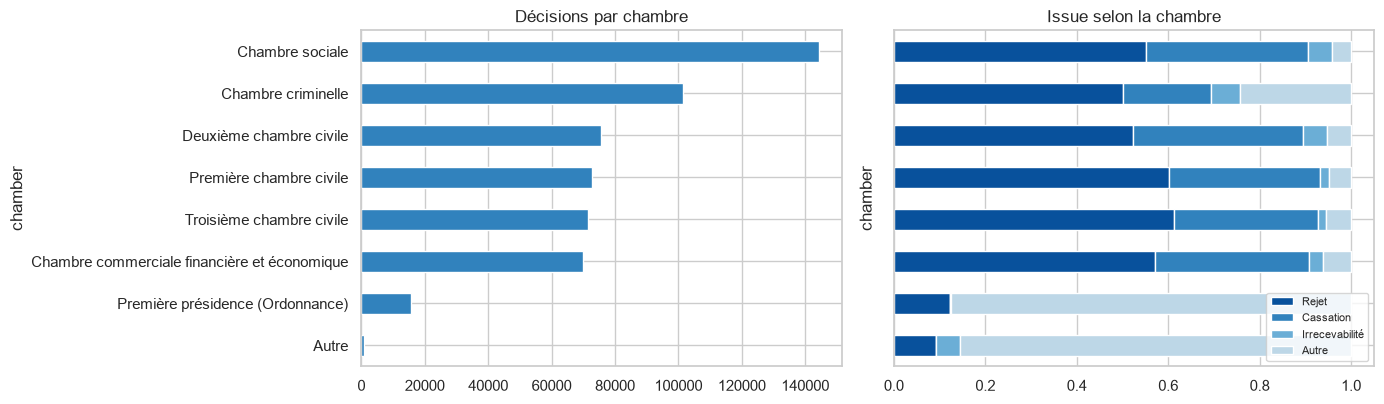

label,Rejet,Cassation,Irrecevabilité,Autre
chamber,,,,
Chambre sociale,0.551,0.355,0.051,0.042
Chambre criminelle,0.500,0.193,0.063,0.244
Deuxième chambre civile,0.523,0.371,0.051,0.054
Première chambre civile,0.602,0.331,0.018,0.049
Troisième chambre civile,0.613,0.315,0.017,0.055
Chambre commerciale financière et économique,0.571,0.338,0.030,0.062
Première présidence (Ordonnance),0.123,0.000,0.001,0.876
Autre,0.092,0.000,0.053,0.856


In [5]:
ch = stats["chamber"].value_counts().head(8)
cross = pd.crosstab(stats["chamber"], stats["label"], normalize="index").loc[ch.index, ["Rejet", "Cassation", "Irrecevabilité", "Autre"]]

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ch.plot.barh(ax=ax[0], color="#3182bd"); ax[0].invert_yaxis(); ax[0].set_title("Décisions par chambre")
cross.plot.barh(stacked=True, ax=ax[1], color=["#08519c", "#3182bd", "#6baed6", "#bdd7e7"]); ax[1].invert_yaxis()
ax[1].set_title("Issue selon la chambre"); ax[1].set_yticklabels([]); ax[1].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.savefig(f"{FIG}/eda_chambers.png", dpi=150); plt.show()
cross.round(3)

**Observation :** l'issue dépend de la chambre. Les chambres civiles, sociale et commerciale cassent dans 31 à 37 % des cas.
La **chambre criminelle** casse moins (19 %) et a beaucoup plus d'issues « Autre » (24 % : non-lieux, désistements, déchéances…).
Les ordonnances de la **Première présidence** sont presque toutes « Autre ».

## 5. Longueur des textes

Point clé pour le choix des modèles : CamemBERT ne lit que **512 tokens** (≈ 350-400 mots français).

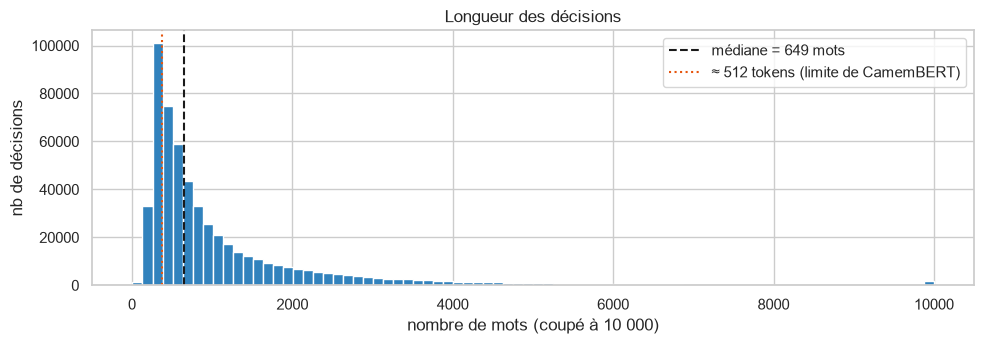

Total : 639,040,461 mots
Médiane : 649 mots | 90e percentile : 2579 | max : 183,503
Décisions plus longues que 512 tokens (~380 mots) : 75.5%


In [6]:
w = stats["n_words"]
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.hist(w.clip(upper=10_000), bins=80, color="#3182bd")
ax.axvline(w.median(), color="k", ls="--", label=f"médiane = {w.median():.0f} mots")
ax.axvline(380, color="#e6550d", ls=":", label="≈ 512 tokens (limite de CamemBERT)")
ax.set_xlabel("nombre de mots (coupé à 10 000)"); ax.set_ylabel("nb de décisions"); ax.legend()
ax.set_title("Longueur des décisions")
plt.tight_layout(); plt.savefig(f"{FIG}/eda_length.png", dpi=150); plt.show()

print(f"Total : {w.sum():,} mots")
print(f"Médiane : {w.median():.0f} mots | 90e percentile : {w.quantile(.9):.0f} | max : {w.max():,}")
print(f"Décisions plus longues que 512 tokens (~380 mots) : {(w > 380).mean():.1%}")

**Observation :** médiane de 649 mots, et **75 %** des décisions dépassent la limite de CamemBERT. On ne peut pas lui donner
le texte entier : il faut choisir **une zone** (les motivations) et la couper intelligemment (on garde la fin, où la Cour conclut).

## 6. Les champs sont-ils remplis ?

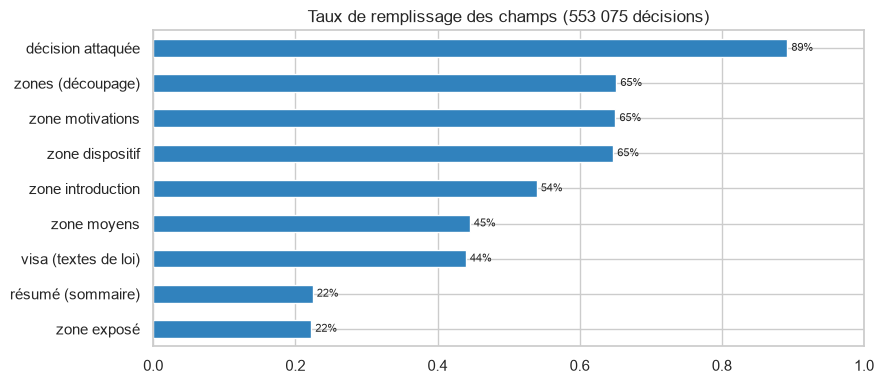

In [7]:
fill = pd.Series({
    "zones (découpage)": stats["has_zones"].mean(),
    "zone introduction": stats["zone_introduction"].mean(),
    "zone exposé": stats["zone_expose"].mean(),
    "zone moyens": stats["zone_moyens"].mean(),
    "zone motivations": stats["zone_motivations"].mean(),
    "zone dispositif": stats["zone_dispositif"].mean(),
    "visa (textes de loi)": (stats["n_visa"] > 0).mean(),
    "décision attaquée": stats["has_contested"].mean(),
    "résumé (sommaire)": stats["has_summary"].mean(),
}).sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
fill.plot.barh(ax=ax, color="#3182bd"); ax.set_xlim(0, 1); ax.set_title("Taux de remplissage des champs (553 075 décisions)")
for c in ax.containers: ax.bar_label(c, fmt="%.0f%%", labels=[f"{v:.0%}" for v in fill.values], padding=3, fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIG}/eda_completeness.png", dpi=150); plt.show()

In [8]:
stats["période"] = pd.cut(stats["year"], [0, 1989, 1999, 2009, 2019, 2100], labels=["avant 1990", "1990-1999", "2000-2009", "2010-2019", "2020+"])
stats.groupby("période", observed=True)[["has_zones", "zone_motivations", "zone_dispositif", "zone_expose"]].mean().round(3)

,has_zones,zone_motivations,zone_dispositif,zone_expose
période,,,,
avant 1990,0.082,0.082,0.081,0.013
1990-1999,0.730,0.728,0.719,0.198
2000-2009,0.797,0.795,0.793,0.261
2010-2019,0.520,0.520,0.520,0.240
2020+,0.992,0.991,0.992,0.374


**Observations :**
- Environ **65 %** des décisions ont un découpage en zones. Les **motivations** et le **dispositif** sont presque
  toujours présents quand il y a des zones ; l'**exposé** et les **moyens** manquent souvent.
- Les décisions les plus anciennes n'ont pas de zones : elles ne peuvent pas servir pour notre tâche.
- C'est pourquoi le corpus des modèles (100 000 décisions) est tiré parmi les décisions **qui ont** motivations et dispositif.

## 7. Le corpus des modèles est-il représentatif ?

In [9]:
comp = pd.DataFrame({
    "base complète": stats["label"].value_counts(normalize=True),
    "base avec zones": stats[stats["zone_motivations"] & stats["zone_dispositif"]]["label"].value_counts(normalize=True),
    "corpus modèles (100k)": corpus["label"].value_counts(normalize=True),
}).loc[["Rejet", "Cassation", "Irrecevabilité", "Autre"]].round(3)
comp

,base complète,base avec zones,corpus modèles (100k)
label,,,
Rejet,0.542,0.554,0.554
Cassation,0.307,0.256,0.256
Irrecevabilité,0.040,0.048,0.049
Autre,0.111,0.142,0.141


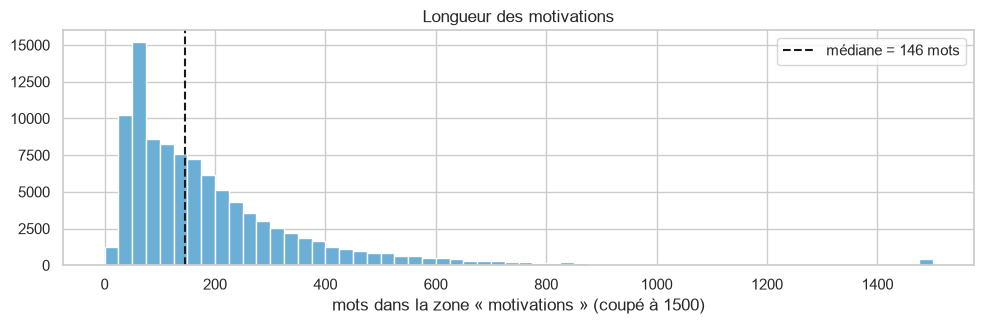

Motivations : médiane 146 mots, 90e percentile 424 mots


In [10]:
mw = corpus["motivations"].str.split().str.len()
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.hist(mw.clip(upper=1500), bins=60, color="#6baed6")
ax.axvline(mw.median(), color="k", ls="--", label=f"médiane = {mw.median():.0f} mots")
ax.set_xlabel("mots dans la zone « motivations » (coupé à 1500)"); ax.legend(); ax.set_title("Longueur des motivations")
plt.tight_layout(); plt.savefig(f"{FIG}/eda_motivations_length.png", dpi=150); plt.show()
print(f"Motivations : médiane {mw.median():.0f} mots, 90e percentile {mw.quantile(.9):.0f} mots")

**Observation :** les motivations sont **courtes** (≈ 150 mots en médiane), donc elles rentrent presque toujours
dans les 256 tokens donnés à CamemBERT. C'est un bon choix d'entrée pour les modèles.

## 8. Quels mots distinguent les issues ?

On compte les mots les plus **caractéristiques** de chaque classe dans les motivations (sur 20 000 décisions),
en comparant leur fréquence dans la classe à leur fréquence globale.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

sample = corpus.sample(20_000, random_state=42)
stop = ["le", "la", "les", "de", "des", "du", "que", "qui", "et", "en", "un", "une", "à", "au", "aux", "a", "d", "l",
        "qu", "par", "pour", "sur", "dans", "il", "elle", "son", "sa", "ses", "ce", "cette", "est", "été", "ont", "se"]
cv = CountVectorizer(ngram_range=(1, 2), min_df=20, stop_words=stop)
X = cv.fit_transform(sample["motivations"])
vocab = np.array(cv.get_feature_names_out())
freq_all = np.asarray(X.sum(0)).ravel() / X.sum()

top = {}
for label in ["Rejet", "Cassation", "Irrecevabilité", "Autre"]:
    Xl = X[(sample["label"] == label).values]
    freq_l = np.asarray(Xl.sum(0)).ravel() / Xl.sum()
    score = np.log((freq_l + 1e-6) / (freq_all + 1e-6)) * (freq_l > 2e-4)
    top[label] = vocab[np.argsort(score)[::-1][:12]]
pd.DataFrame(top)

,Rejet,Cassation,Irrecevabilité,Autre
0,attaquée manifestement,conséquences cassation,irrecevable même,siège adresse
1,annexés sont,portée conséquences,même pourvoi,tant recevabilité
2,cassation annexés,ainsi alors,607 608,recours pièces
3,annexé invoqué,fondé vu,cassation omission,examiné tant
4,invoqué encontre,susvisé vu,articles 606,constate existe
5,cassation annexé,violé texte,606 607,existe espèce
6,sont invoqués,attendu débouter,articles 973,mme caroline
7,civile donc,suit cassation,pas réparée,caroline azar
8,invoqués encontre,cassation encourue,sommaire tel,adresse formé
9,cassation donc,cour vu,production mémoire,espèce aucun


**Observation :** les mots caractéristiques ont un vrai sens juridique :
- *Rejet* : « manifestement », « moyens annexés », « invoqués à l'encontre » : formules des rejets non spécialement motivés
  (« les griefs ne sont manifestement pas de nature à entraîner la cassation ») ;
- *Cassation* : « violé le texte », « susvisé », « cassation encourue », « portée et conséquences de la cassation » ;
- *Irrecevabilité* : « irrecevable », « articles 606, 607, 608 » (textes sur la recevabilité des pourvois), « production du mémoire » ;
- *Autre* : vocabulaire des ordonnances (« présente ordonnance », « siège », « adresse »)… et un **nom de magistrat**
  (« Mme Caroline Azar »). Ce dernier point est un **raccourci** : un modèle peut apprendre qui signe la décision
  plutôt que le raisonnement. On le garde en tête pour l'analyse critique.

C'est rassurant : un modèle de NLP a de quoi apprendre à partir des motivations.

## 9. Conclusions pour la suite

| Constat | Conséquence pour les modèles |
|---|---|
| 553 075 décisions, 639 M de mots | trop pour CamemBERT sur un Mac : échantillon de 100 000 (20 000 pour CamemBERT) |
| Classes déséquilibrées (54 % rejet) | métrique **F1 macro**, poids de classes |
| Textes très longs (médiane 649 mots, 75 % > 512 tokens) | on travaille sur une zone : les **motivations** (médiane ~150 mots) |
| Le dispositif écrit la réponse | le dispositif est traité par **règles** ; les modèles lisent les motivations |
| Anciennes décisions sans zones | corpus tiré parmi les décisions avec zones |
| Styles d'écriture différents selon l'époque | analyse des erreurs par période |